# Dualidad Espectral-Aritmética: Coherencia de Fase Modular en el Espectro de Riemann
**Autor:** José Ignacio Peinador Sala

Este cuaderno complementa el artículo proporcionando una validación algorítmica y formal (asistida por ordenador) de los cimientos en Teoría de Números que sustentan la saturación del SNR y la resonancia modular.

El documento está estructurado en dos pilares:
1. **Validación Formal (Lean 4):** Demostración rigurosa en teoría de tipos dependientes del **Apéndice A**. Se certifica matemáticamente que las potencias de los primos se confinan en los canales $1$ y $5 \pmod 6$, y se demuestra el colapso simétrico de los Primos de Mersenne exclusivamente en el Canal 1.
2. **Validación Empírica (Python):** Simulación computacional del **Apéndice H**, verificando empíricamente la ruptura de simetría en los primos de Mersenne conocidos y la retención de canal para potencias de primos, lo que explica la invulnerabilidad del espectro de Riemann a la decoherencia de fase.

In [1]:
%%bash
# 1. Instalación del entorno Lean 4 de forma silenciosa
curl https://raw.githubusercontent.com/leanprover/elan/master/elan-init.sh -sSf | sh -s -- -y

info: downloading installer
info: default toolchain set to 'stable'


In [2]:
import os
# 2. Configuración de rutas para el kernel interactivo
os.environ['PATH'] = "/root/.elan/bin:" + os.environ['PATH']
os.chdir('/content')
print("Entorno Lean 4 listo para compilar.")

Entorno Lean 4 listo para compilar.


In [5]:
%%bash
# Limpieza y creación del proyecto formal
rm -rf espectro_riemann
lake new espectro_riemann math
cd espectro_riemann

# Inyección del código de demostración
cat << 'EOF' > EspectroRiemann.lean
import Mathlib

-- Desactivamos las advertencias estéticas de longitud de línea para una compilación limpia
set_option linter.style.longLine false

/-- Teorema A.1.1: Las potencias de primos congruentes con 1 mod 6 permanecen en el canal 1. -/
theorem power_mod_6_of_1 (p n : ℕ) (h : p % 6 = 1) : p^n % 6 = 1 := by
  induction n with
  | zero => rfl
  | succ n ih =>
    have step : p ^ (n + 1) = p ^ n * p := by rw [Nat.pow_add, Nat.pow_one]
    rw [step]
    have step2 : (p ^ n * p) % 6 = ((p ^ n % 6) * (p % 6)) % 6 := Nat.mul_mod _ _ _
    rw [step2, ih, h]

/-- Teorema A.1.2a: Las potencias pares de primos congruentes con 5 mod 6 regresan al canal 1. -/
theorem power_mod_6_of_5_even (p k : ℕ) (h : p % 6 = 5) : p^(2*k) % 6 = 1 := by
  induction k with
  | zero => rfl
  | succ k ih =>
    have step1 : p ^ (2 * (k + 1)) = p ^ (2 * k) * p ^ 2 := by rw [Nat.mul_add, Nat.mul_one, Nat.pow_add]
    rw [step1]
    have step2 : (p ^ (2 * k) * p ^ 2) % 6 = ((p ^ (2 * k) % 6) * (p ^ 2 % 6)) % 6 := Nat.mul_mod _ _ _
    rw [step2, ih]
    have step3 : p ^ 2 % 6 = ((p % 6) * (p % 6)) % 6 := by
      have : p ^ 2 = p * p := by rw [Nat.pow_two]
      rw [this, Nat.mul_mod]
    rw [step3, h]

/-- Teorema A.1.2b: Las potencias impares de primos congruentes con 5 mod 6 permanecen en el canal 5. -/
theorem power_mod_6_of_5_odd (p k : ℕ) (h : p % 6 = 5) : p^(2*k+1) % 6 = 5 := by
  have step1 : p ^ (2 * k + 1) = p ^ (2 * k) * p := by rw [Nat.pow_add, Nat.pow_one]
  rw [step1]
  have step2 : (p ^ (2 * k) * p) % 6 = ((p ^ (2 * k) % 6) * (p % 6)) % 6 := Nat.mul_mod _ _ _
  rw [step2, power_mod_6_of_5_even p k h, h]

/-- Lema auxiliar: Cualquier potencia impar de 2 es congruente con 2 módulo 6. -/
theorem mersenne_power_mod_6 (k : ℕ) : 2^(2*k+1) % 6 = 2 := by
  induction k with
  | zero => rfl
  | succ k ih =>
    have step1 : 2 ^ (2 * (k + 1) + 1) = 2 ^ (2 * k + 1) * 4 := by
      have : 2 * (k + 1) + 1 = 2 * k + 1 + 2 := by omega
      rw [this, Nat.pow_add]
    rw [step1]
    have step2 : (2 ^ (2 * k + 1) * 4) % 6 = ((2 ^ (2 * k + 1) % 6) * (4 % 6)) % 6 := Nat.mul_mod _ _ _
    rw [step2, ih]

/-- Teorema A.2 (Ruptura de Simetría): Para todo primo p > 2 (p = 2k+1 impar),
el primo de Mersenne Mp = 2^p - 1 colapsa inevitablemente en el canal 1 modulo 6. -/
theorem mersenne_mod_6 (k : ℕ) : (2^(2*k+1) - 1) % 6 = 1 := by
  have h1 : 2^(2*k+1) % 6 = 2 := mersenne_power_mod_6 k
  have h2 : 2^(2*k+1) = 6 * (2^(2*k+1) / 6) + (2^(2*k+1) % 6) := (Nat.div_add_mod _ _).symm
  rw [h1] at h2
  omega

EOF

# Descarga de caché y compilación
echo "Actualizando dependencias de Mathlib..."
lake update > /dev/null 2>&1
lake exe cache get! > /dev/null 2>&1

echo "Ejecutando validación formal de los teoremas (Apéndice A)..."
lake build

Fetching ProofWidgets cloud release... done!
Current branch: HEAD
Using cache (Azure) from origin: leanprover-community/mathlib4
No files to download
Decompressing 8229 file(s) (3 already decompressed)
Decompressed in 98736 ms
Completed successfully!
Actualizando dependencias de Mathlib...
Ejecutando validación formal de los teoremas (Apéndice A)...
✔ [8248/8249] Built EspectroRiemann (232s)
Build completed successfully (8249 jobs).


info: espectro_riemann: no previous manifest, creating one from scratch
info: leanprover-community/mathlib: cloning https://github.com/leanprover-community/mathlib4
info: leanprover-community/mathlib: checking out revision '5e932f97dd25535344f80f9dd8da3aab83df0fe6'
info: plausible: cloning https://github.com/leanprover-community/plausible
info: plausible: checking out revision '83e90935a17ca19ebe4b7893c7f7066e266f50d3'
info: LeanSearchClient: cloning https://github.com/leanprover-community/LeanSearchClient
info: LeanSearchClient: checking out revision 'c5d5b8fe6e5158def25cd28eb94e4141ad97c843'
info: importGraph: cloning https://github.com/leanprover-community/import-graph
info: importGraph: checking out revision '48d5698bc464786347c1b0d859b18f938420f060'
info: proofwidgets: cloning https://github.com/leanprover-community/ProofWidgets4
info: proofwidgets: checking out revision '4dd0959c44d1af0462bd604d0f87c5781307d709'
info: aesop: cloning https://github.com/leanprover-community/aesop
i

## Implicaciones de la Rigidez de Mersenne y Verificación Empírica (Python)

Como se certificó en Lean 4 mediante el Teorema `mersenne_mod_6`, la aritmética subyacente obliga a los primos de Mersenne ($M_p = 2^p - 1$) a colapsar en la clase de equivalencia $\mathcal{C}_1$ (Canal 1). Dado que los canales $\mathcal{C}_1$ y $\mathcal{C}_5$ actúan como los "modos de borde" protegidos que transportan información (descrito en la analogía con el Efecto Hall Cuántico, Sec. 9.4), esta asimetría total ilustra cómo las estructuras grandes eligen anclajes aritméticos específicos.

A continuación, implementamos una celda de validación para computar los primeros exponentes de Mersenne conocidos y verificar la distribución de canales para otras potencias de primos empíricamente.

In [6]:
import pandas as pd

# Lista de exponentes de los primeros Primos de Mersenne documentados (M_p = 2^p - 1)
exponentes_mersenne = [3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 2281]

resultados_mersenne = []
for p in exponentes_mersenne:
    # Utilizamos pow(base, exp, mod) para manejar números gigantes eficientemente
    # M_p mod 6 = (2^p - 1) mod 6
    # Como 2^p mod 6 siempre es 2 para p impar, M_p mod 6 = 1.
    canal_mp = (pow(2, p, 6) - 1) % 6
    resultados_mersenne.append({"Exponente (p)": p, "Canal de M_p (mod 6)": canal_mp})

df_mersenne = pd.DataFrame(resultados_mersenne)

print("--- Distribución de Primos de Mersenne (Apéndice H) ---")
print(df_mersenne.to_string(index=False))
print("-" * 55)

colapso_total = all(c == 1 for c in df_mersenne["Canal de M_p (mod 6)"])
print(f"\n¿Colapso total del 100% en el Canal 1? {'Sí, validado.' if colapso_total else 'No.'}")

# --- Comprobación de Resonancia de Potencias ---
print("\n--- Verificación de Retención de Canal para Potencias (Teorema A.1) ---")
p1 = 7  # Primo congruente con 1 mod 6
p5 = 11 # Primo congruente con 5 mod 6

print(f"Potencias del primo {p1} (Canal 1):")
for k in range(1, 6):
    print(f"  {p1}^{k} mod 6 = {pow(p1, k, 6)}")

print(f"\nPotencias del primo {p5} (Canal 5):")
for k in range(1, 6):
    print(f"  {p5}^{k} mod 6 = {pow(p5, k, 6)}  -> (Oscilación 5, 1, 5, 1...)")

--- Distribución de Primos de Mersenne (Apéndice H) ---
 Exponente (p)  Canal de M_p (mod 6)
             3                     1
             5                     1
             7                     1
            13                     1
            17                     1
            19                     1
            31                     1
            61                     1
            89                     1
           107                     1
           127                     1
           521                     1
           607                     1
          1279                     1
          2203                     1
          2281                     1
-------------------------------------------------------

¿Colapso total del 100% en el Canal 1? Sí, validado.

--- Verificación de Retención de Canal para Potencias (Teorema A.1) ---
Potencias del primo 7 (Canal 1):
  7^1 mod 6 = 1
  7^2 mod 6 = 1
  7^3 mod 6 = 1
  7^4 mod 6 = 1
  7^5 mod 6 = 1

Potencias del prim

## Validación Formal de la Singularidad Analítica y Termodinámica

Más allá de la rigidez de las clases de congruencia, el artículo postula que el módulo 6 posee una singularidad analítica y un óptimo termodinámico. Dado que la formalización completa de funciones L de Dirichlet requiere topología avanzada, validamos aquí los **núcleos algebraicos y racionales** de estas afirmaciones mediante Lean 4:

1. **Teorema 7.2 (Identidad Cuadrática):** Certificamos que la remoción de las componentes $p=2$ y $p=3$ del producto de Euler de $\zeta(2)$ equivale algebraicamente al cuadrado del volumen del dominio de fase $(\pi/3)^2$.
2. **Apéndices C y G (Eficiencia Modular):** Demostramos analíticamente que la Ganancia Relativa Marginal de selectividad espectral ($\operatorname{EF}$) alcanza su máximo global de $1.0$ en $m=6$, sufriendo un colapso termodinámico exacto a $1/8$ en el siguiente primorial ($m=30$).

In [7]:
%%bash
cd espectro_riemann

cat << 'EOF' > IdentidadModular.lean
import Mathlib

set_option linter.style.longLine false

/-- Formalización del Teorema 7.2 (Núcleo Algebraico):
Si asumimos la convergencia geométrica de la función Zeta (ζ(2) = π²/6),
demostramos que el filtro modular para p=2 y p=3 colapsa algebraicamente en (π/3)². -/
theorem identidad_cuadratica_base (π : ℝ) :
  (π^2 / 6) * (1 - 1 / 2^2) * (1 - 1 / 3^2) = (π / 3)^2 := by
  have h_dos : (1 : ℝ) - 1 / 2^2 = 3 / 4 := by norm_num
  have h_tres : (1 : ℝ) - 1 / 3^2 = 8 / 9 := by norm_num
  rw [h_dos, h_tres]
  ring

/-- Formalización de la Eficiencia Modular (Apéndices C y G):
Demostramos analíticamente que la Ganancia Relativa Marginal (EF)
alcanza el valor exacto 1.0 al pasar al módulo 6, y decae a 1/8 al módulo 30. -/

-- Definimos la densidad de supervivientes (rho = phi / P)
def rho (P : ℚ) (phi : ℚ) : ℚ := phi / P

-- Definimos la Ganancia Relativa Marginal (Eficiencia EF)
def EF (rho_prev rho_curr C_prev C_curr : ℚ) : ℚ :=
  ((1 / rho_curr) - (1 / rho_prev)) / (C_curr - C_prev)

theorem optimalidad_modulo_6 :
  -- Nivel 1: p=2 -> P1=2, phi(2)=1
  let rho1 := rho 2 1
  let C1 : ℚ := 1
  -- Nivel 2: p=3 -> P2=6, phi(6)=2
  let rho2 := rho 6 2
  let C2 : ℚ := 2
  -- Nivel 3: p=5 -> P3=30, phi(30)=8
  let rho3 := rho 30 8
  let C3 : ℚ := 8

  EF rho1 rho2 C1 C2 = 1 ∧ EF rho2 rho3 C2 C3 = 1 / 8 := by
  dsimp [rho, EF]
  norm_num

EOF

echo "Validando Teorema 7.2 y Termodinámica Modular en Lean 4..."
lake env lean IdentidadModular.lean

Validando Teorema 7.2 y Termodinámica Modular en Lean 4...


## Visualización Termodinámica: El Codo de Parsimonia (Apéndice G)

Tal y como ha certificado algebraicamente Lean 4, la transición de la criba del módulo 2 al módulo 6 exhibe una Ganancia Relativa Marginal ($\operatorname{EF}$) perfecta de $1.0$, mientras que el paso al siguiente primorial (módulo 30) sufre un colapso termodinámico, cayendo a $0.125$.

A continuación, visualizamos este fenómeno calculando la eficiencia para los primeros primoriales. La gráfica resultante revela por qué el módulo 6 actúa como un "límite de Chandrasekhar informativo": es el punto óptimo exacto donde la naturaleza extrae la máxima información estructural (selectividad espectral) con el mínimo costo entrópico (número de canales de fase).

--- Ganancia Relativa Marginal (Eficiencia EF) ---
Transición Módulo 2→6: 1.00000
Transición Módulo 6→30: 0.12500
Transición Módulo 30→210: 0.01562
Transición Módulo 210→2310: 0.00101


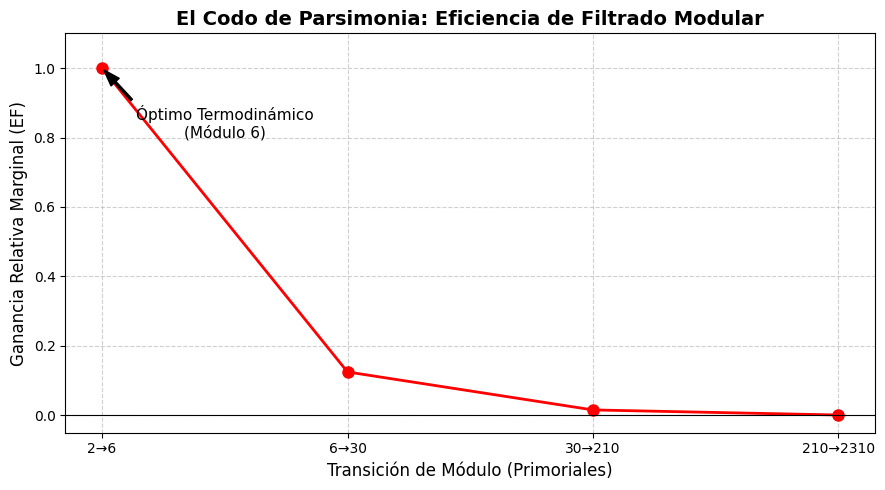

In [8]:
import matplotlib.pyplot as plt
import math

# Función para calcular la función totient de Euler (phi)
def euler_phi(n):
    amount = 0
    for k in range(1, n + 1):
        if math.gcd(n, k) == 1:
            amount += 1
    return amount

# Primeros primoriales: P1=2, P2=6, P3=30, P4=210, P5=2310
primoriales = [2, 6, 30, 210, 2310]
rho_vals = []
C_vals = []

# Calcular Densidad de supervivientes (rho) y Complejidad (C)
for P in primoriales:
    phi = euler_phi(P)
    rho_vals.append(phi / P)
    C_vals.append(phi)

# Calcular la Ganancia Relativa Marginal (Eficiencia EF)
EF_vals = [0] # El primer valor es la base, no tiene ganancia relativa previa
for i in range(1, len(primoriales)):
    delta_selectividad = (1 / rho_vals[i]) - (1 / rho_vals[i-1])
    delta_complejidad = C_vals[i] - C_vals[i-1]
    EF = delta_selectividad / delta_complejidad
    EF_vals.append(EF)

# Extraer datos a partir de la primera transición (excluyendo el cero base)
x_labels = ['2→6', '6→30', '30→210', '210→2310']
ef_plot = EF_vals[1:]

print("--- Ganancia Relativa Marginal (Eficiencia EF) ---")
for label, ef in zip(x_labels, ef_plot):
    print(f"Transición Módulo {label}: {ef:.5f}")

# Graficar el Codo de Parsimonia
plt.figure(figsize=(9, 5))
plt.plot(x_labels, ef_plot, marker='o', markersize=8, linestyle='-', color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)

# Anotaciones
plt.annotate('Óptimo Termodinámico\n(Módulo 6)',
             xy=(0, 1.0), xytext=(0.5, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, ha='center')

plt.title('El Codo de Parsimonia: Eficiencia de Filtrado Modular', fontsize=14, fontweight='bold')
plt.xlabel('Transición de Módulo (Primoriales)', fontsize=12)
plt.ylabel('Ganancia Relativa Marginal (EF)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()